In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.special import expit
import pymc as pm
import arviz as az

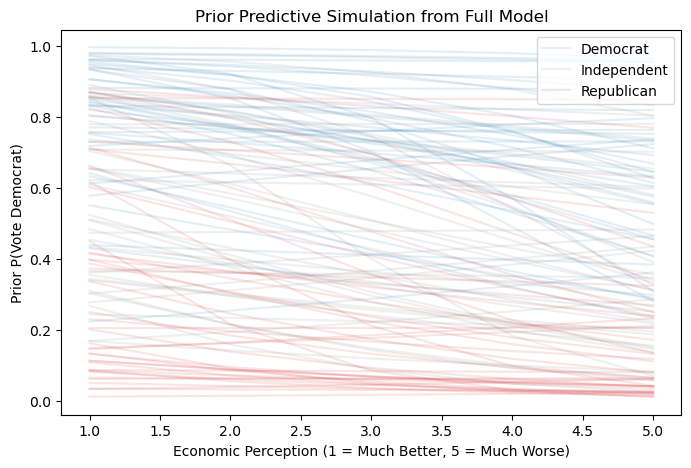

,party_id,econ_perception,mean_prior_p,mean_simulated_vote
0,Democrat,1,0.809881,0.92
1,Democrat,2,0.776392,0.78
2,Democrat,3,0.732580,0.72
3,Democrat,4,0.678346,0.74
4,Democrat,5,0.618492,0.56
5,Independent,1,0.573285,0.66
6,Independent,2,0.519290,0.50
7,Independent,3,0.462188,0.48
8,Independent,4,0.406742,0.42
9,Independent,5,0.357227,0.34


In [3]:


# ----------------------------
# Prior predictive simulation
# ----------------------------

np.random.seed(42)

n_samples = 50
econ = np.arange(1, 6)
econ_centered = econ - 3

party_labels = ["Democrat", "Independent", "Republican"]

# Priors for model parameters
alpha_samples = np.random.normal(loc=0, scale=1, size=n_samples)

# Prior belief: worse economy should usually reduce Democratic incumbent vote
beta_econ_samples = np.random.normal(loc=-0.3, scale=0.3, size=n_samples)

# Party ID prior effects on logit scale
party_effect_samples = {
    "Democrat": np.random.normal(loc=1.5, scale=0.7, size=n_samples),
    "Independent": np.random.normal(loc=0.0, scale=0.5, size=n_samples),
    "Republican": np.random.normal(loc=-1.5, scale=0.7, size=n_samples),
}

# Store simulated results
sim_rows = []

for i in range(n_samples):
    for party in party_labels:
        for e, ec in zip(econ, econ_centered):
            logit_p = (
                alpha_samples[i]
                + beta_econ_samples[i] * ec
                + party_effect_samples[party][i]
            )
            p = expit(logit_p)

            # Simulated vote outcome from Bernoulli model
            y_sim = np.random.binomial(n=1, p=p)

            sim_rows.append({
                "simulation": i,
                "econ_perception": e,
                "party_id": party,
                "p_vote_dem": p,
                "simulated_vote_dem": y_sim
            })

prior_sim_df = pd.DataFrame(sim_rows)

# ----------------------------
# Plot simulated probabilities
# ----------------------------

fig, ax = plt.subplots(figsize=(8, 5))

# Define colors
party_colors = {
    "Democrat": "#1f77b4",     # blue
    "Republican": "#d62728",   # red
    "Independent": "#7f7f7f"   # gray
}

for party in party_labels:
    party_df = prior_sim_df[prior_sim_df["party_id"] == party]

    for sim_id in party_df["simulation"].unique()[:40]:
        temp = party_df[party_df["simulation"] == sim_id]
        ax.plot(
            temp["econ_perception"],
            temp["p_vote_dem"],
            color=party_colors[party],
            alpha=0.12,
            label=party if sim_id == 0 else None
        )

ax.set_xlabel("Economic Perception (1 = Much Better, 5 = Much Worse)")
ax.set_ylabel("Prior P(Vote Democrat)")
ax.set_title("Prior Predictive Simulation from Full Model")

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

prior_full_model_plot = ax
plt.show()

# ----------------------------
# Summarize simulated outcomes
# ----------------------------

summary = (
    prior_sim_df
    .groupby(["party_id", "econ_perception"])
    .agg(
        mean_prior_p=("p_vote_dem", "mean"),
        mean_simulated_vote=("simulated_vote_dem", "mean")
    )
    .reset_index()
)

summary

In [4]:
# Load processed data
df = pd.read_csv("../data/processed/cleaned_data.csv")

# Explicit party coding
# Independent = baseline
party_map = {
    "Independent": 0,
    "Democrat": 1,
    "Republican": 2
}

df["party_code"] = df["party_id"].map(party_map)

# Prepare variables
econ_centered = df["econ_perception"].to_numpy(dtype="float64") - 3
party = df["party_code"].to_numpy(dtype="int64")
y = df["voted_dem_house"].to_numpy(dtype="int64")

# Model
with pm.Model() as vote_model:
    
    # Priors
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta_econ = pm.Normal("beta_econ", mu=-0.3, sigma=0.3)

    # Party effects with Independent as baseline
    gamma_raw = pm.Normal("gamma_raw", mu=0, sigma=1.5, shape=2)
    gamma_party = pm.math.concatenate([[0], gamma_raw])

    # Linear predictor
    logit_p = alpha + beta_econ * econ_centered + gamma_party[party]

    # Likelihood
    vote = pm.Bernoulli(
        "vote",
        logit_p=logit_p,
        observed=y
    )

    # MCMC sampling
    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

# Summary
az.summary(idata, var_names=["alpha", "beta_econ", "gamma_raw"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_econ, gamma_raw]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.248,0.035,1.184,1.314,0.001,0.001,1643.0,2189.0,1.0
beta_econ,-1.031,0.020,-1.069,-0.996,0.000,0.000,2016.0,2232.0,1.0
gamma_raw[0],2.658,0.045,2.572,2.740,0.001,0.001,2589.0,2579.0,1.0
gamma_raw[1],-2.766,0.053,-2.863,-2.669,0.001,0.001,2512.0,2987.0,1.0


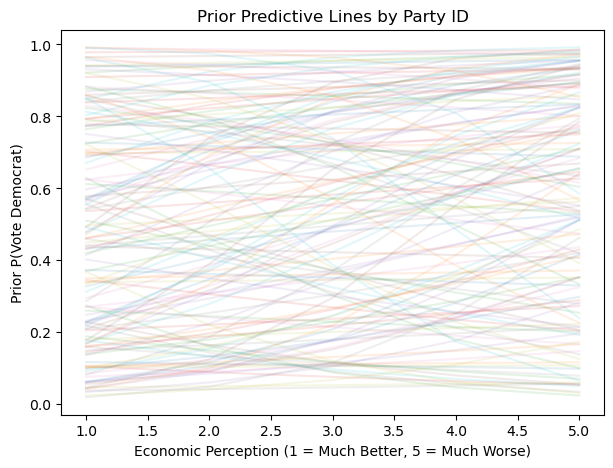

In [ ]:
n_samples = 50

econ = np.arange(1, 6)
econ_centered = econ - 3

party_labels = ["Democrat", "Independent", "Republican"]
party_offsets = {
    "Democrat": 1.5,
    "Independent": 0.0,
    "Republican": -1.5
}

alpha_samples = np.random.normal(loc=0, scale=1, size=n_samples)
beta_samples = np.random.normal(loc=0, scale=0.5, size=n_samples)

fig, ax = plt.subplots(figsize=(7, 5))

for party in party_labels:
    for i in range(n_samples):
        logit_p = (
            alpha_samples[i]
            + beta_samples[i] * econ_centered
            + party_offsets[party]
        )
        p = expit(logit_p)
        ax.plot(econ, p, alpha=0.12)

ax.set_xlabel("Economic Perception (1 = Much Better, 5 = Much Worse)")
ax.set_ylabel("Prior P(Vote Democrat)")
ax.set_title("Prior Predictive Lines by Party ID")

prior_party_plot = ax

plt.show()

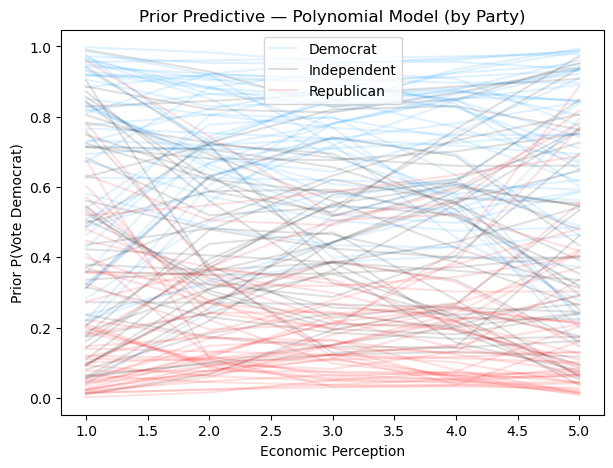

In [11]:
from scipy.special import expit
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_samples = 50

econ = np.arange(1, 6)
econ_centered = econ - 3

party_labels = ["Democrat", "Independent", "Republican"]
party_offsets = {
    "Democrat": 1.5,
    "Independent": 0.0,
    "Republican": -1.5
}

# Colors for each party
party_colors = {
    "Democrat": "#0095ff",     # blue
    "Independent": "#000000",  # gray
    "Republican": "#ff0000"    # red
}

# Priors
alpha_samples = np.random.normal(loc=0, scale=1, size=n_samples)
beta1_samples = np.random.normal(loc=0, scale=0.5, size=n_samples)
beta2_samples = np.random.normal(loc=0, scale=0.3, size=n_samples)

fig, ax = plt.subplots(figsize=(7, 5))

for party in party_labels:
    for i in range(n_samples):
        logit_p = (
            alpha_samples[i]
            + beta1_samples[i] * econ_centered
            + beta2_samples[i] * (econ_centered ** 2)
            + party_offsets[party]
        )
        p = expit(logit_p)

        ax.plot(
            econ,
            p,
            color=party_colors[party],
            alpha=0.12,
            label=party if i == 0 else None
        )

# Clean legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

ax.set_xlabel("Economic Perception")
ax.set_ylabel("Prior P(Vote Democrat)")
ax.set_title("Prior Predictive — Polynomial Model (by Party)")

prior_poly_plot = ax
plt.show()

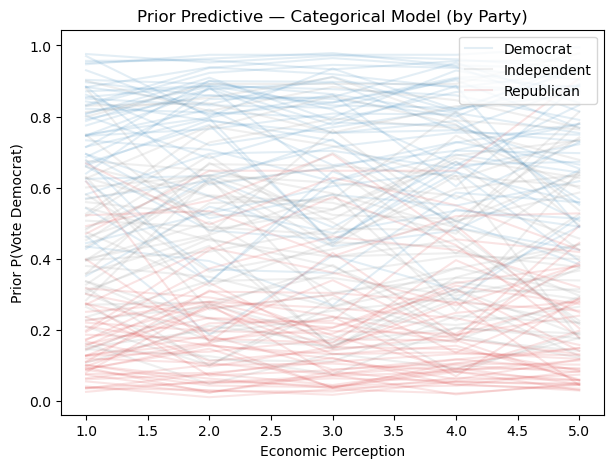

In [8]:
np.random.seed(42)

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

np.random.seed(42)

n_samples = 50
econ = np.arange(1, 6)

party_labels = ["Democrat", "Independent", "Republican"]
party_offsets = {
    "Democrat": 1.5,
    "Independent": 0.0,
    "Republican": -1.5
}

# Colors for each party
party_colors = {
    "Democrat": "#1f77b4",     # blue
    "Independent": "#7f7f7f",  # gray
    "Republican": "#d62728"    # red
}

# Priors
alpha_samples = np.random.normal(loc=0, scale=1, size=n_samples)
beta_cat_samples = np.random.normal(loc=0, scale=0.5, size=(n_samples, 5))

fig, ax = plt.subplots(figsize=(7, 5))

for party in party_labels:
    for i in range(n_samples):
        logit_p = (
            alpha_samples[i]
            + beta_cat_samples[i]
            + party_offsets[party]
        )
        p = expit(logit_p)

        ax.plot(
            econ,
            p,
            color=party_colors[party],
            alpha=0.12,
            label=party if i == 0 else None  # label only once
        )

# Clean legend (avoid duplicates)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

ax.set_xlabel("Economic Perception")
ax.set_ylabel("Prior P(Vote Democrat)")
ax.set_title("Prior Predictive — Categorical Model (by Party)")

prior_cat_plot = ax
plt.show()

In [12]:
# Encode party as index

party_map = {"Democrat": 0, "Independent": 1, "Republican": 2}

df["party_idx"] = df["party_id"].map(party_map)

# Outcome

y = df["voted_dem_house"].values

# Party index

party_idx = df["party_idx"].values

# Econ (centered for polynomial)

econ = df["econ_perception"].values

econ_centered = econ - 3

In [19]:
with pm.Model() as poly_model:

    # Priors
    alpha = pm.Normal("alpha", 0, 1)
    beta1 = pm.Normal("beta1", 0, 0.5)
    beta2 = pm.Normal("beta2", 0, 0.3)

    beta_party = pm.Normal("beta_party", 0, 1, shape=3)

    # Linear predictor
    mu = (
        alpha
        + beta1 * econ_centered
        + beta2 * (econ_centered ** 2)
        + beta_party[party_idx]
    )

    # Likelihood
    p = pm.Deterministic("p", pm.math.sigmoid(mu))
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    # Sampling
    poly_trace = pm.sample(1000, tune=1000, target_accept=0.9, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta_party]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 189 seconds.


In [20]:
with pm.Model() as cat_model:

    # Priors
    alpha = pm.Normal("alpha", 0, 1)

    # One parameter per econ level (1–5 → 0–4 index)
    beta_econ = pm.Normal("beta_econ", 0, 0.5, shape=5)

    beta_party = pm.Normal("beta_party", 0, 1, shape=3)

    # Indices (ensure integer)
    econ_idx = df["econ_perception"].values.astype(int) - 1
    party_idx = df["party_idx"].values.astype(int)
    y = df["voted_dem_house"].values.astype(int)

    # Linear predictor
    mu = (
        alpha
        + beta_econ[econ_idx]
        + beta_party[party_idx]
    )

    # Likelihood
    p = pm.Deterministic("p", pm.math.sigmoid(mu))
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    # Sampling
    cat_trace = pm.sample(1000, tune=1000, target_accept=0.9, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_econ, beta_party]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 231 seconds.


In [21]:
# Compute WAIC
poly_waic = az.waic(poly_trace)
cat_waic = az.waic(cat_trace)

print("Polynomial WAIC:\n", poly_waic)
print("\nCategorical WAIC:\n", cat_waic)

az.compare(
    {"Polynomial": poly_trace, "Categorical": cat_trace},
    ic="waic"
)

Polynomial WAIC:
 Computed from 4000 posterior samples and 35628 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -9605.76   115.79
p_waic        5.00        -

Categorical WAIC:
 Computed from 4000 posterior samples and 35628 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -9595.65   115.45
p_waic        7.07        -


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Categorical,0,-9595.647360,7.065295,0.000000,0.891177,115.449556,0.000000,False,log
Polynomial,1,-9605.759045,4.998194,10.111685,0.108823,115.789647,5.096866,False,log



We model the relationship between national economic perception and voting behavior using a Bayesian generalized linear modeling framework consistent with the approaches developed in class. Since the outcome variable (voting for the Democratic candidate) is binary, we specify a Bernoulli likelihood with a logit link function, where the log-odds of voting for the incumbent are modeled as a function of economic perception and party identification. Party identification is included in all specifications as a confounder, following the causal reasoning developed using directed acyclic graphs, since it plausibly influences both economic perception and vote choice.

To evaluate how economic perception should be incorporated into the model, we estimate two competing specifications. The first is a polynomial model, where economic perception is treated as a numeric variable and enters the model through both linear and quadratic terms. This specification imposes a smooth functional form, allowing for curvature while maintaining a structured relationship between perception and vote choice. This approach is directly analogous to the quadratic models used in class to capture non-linear effects in regression settings. The second specification treats economic perception as a categorical variable, assigning a separate parameter to each level of the variable. This approach removes any assumption about equal spacing or smoothness across categories and allows the model to capture arbitrary, potentially non-linear or threshold-like patterns in the data.

Both models are estimated using Bayesian inference with weakly informative priors, and posterior samples are obtained using Markov Chain Monte Carlo. To compare the models, we compute the Widely Applicable Information Criterion (WAIC), which estimates out-of-sample predictive performance based on the expected log pointwise predictive density. The categorical model achieves a higher (less negative) WAIC score than the polynomial model, with an elpd difference of approximately 10, which is about twice its standard error. This provides moderately strong evidence that the categorical specification offers better predictive performance, despite using more parameters. This result suggests that the relationship between economic perception and voting behavior is not well captured by a smooth functional form, and instead exhibits non-linear or threshold-like behavior that is more effectively modeled using a categorical representation.
